# Uncertainty Explainer — Demo Workflow

Este notebook muestra el pipeline completo de la librería:

1. **Datos**: generamos un dataset de regresión sintético
2. **Modelo**: entrenamos un `RandomForestRegressor`
3. **Predicción conformal**: calibramos intervalos de predicción
4. **Explicación**: Explicamos la incertidumbre generada por la predicción conformal.
    - ***Valores Shapley***: explicamos qué features contribuyen a la incertidumbre (ancho del intervalo)
    - ***Partial Dependence Plot (PDP)***: Explicamos cómo cambia la incertidumbre media del modelo cuando cambia las features seleccionadas (efecto marginal).
    - ***LIME***: Para un punto de interés, se ajusta un modelo interpretable localmente que permita interpretar los parámetros sobre la amplitud del intervalo como variable de respuesta.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from uncertainty_explainer.uq_explainer import UncertaintyExplanationPipeline

## 1. Generar datos sintéticos

In [3]:
X, y = make_regression(
    n_samples=1000,
    n_features=5,
    n_informative=5,
    noise=25.0,
    random_state=42,
)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_calib, X_test, y_calib, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape[0]}, Calibracion: {X_calib.shape[0]}, Test: {X_test.shape[0]}")

Train: 600, Calibracion: 200, Test: 200


## 2. Crear el pipeline

El pipeline recibe un regresor sklearn, un método conformal y un método xai.

Metodos conformales soportados (`conformal_method`):
- `"standard"` — conformal basico, intervalos de ancho fijo para todas las instancias
- `"normalized"` — usa `DifficultyEstimator` para adaptar el ancho segun la dificultad de cada instancia (default)
- `"mondrian"` — usa `MondrianCategorizer` para cobertura condicional por grupo
- `"normalized_mondrian"` — combina DifficultyEstimator + MondrianCategorizer

Métodos XAI soportados (`xai_method`):
- `"shap"`
- `"pdp"`
- `"lime"`

## Explanation using valores shapley

In [7]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Metodos disponibles: "standard", "normalized", "mondrian", "normalized_mondrian"
pipeline = UncertaintyExplanationPipeline(
    model,
    confidence=0.9,
    conformal_method="normalized",
)

### 3. Entrenar y calibrar

`fit()` entrena el modelo base y calibra el predictor conformal con el set de calibracion.

In [8]:
pipeline.fit(X_train, y_train, X_calib, y_calib)

### 4. Explicar la incertidumbre

`explain_uncertainty()` calcula valores SHAP sobre el ancho del intervalo conformal y genera plots automaticamente (beeswarm, bar, waterfall).

Este método explicar la métrica de incertidumbre tanto de manera local como global. Si el usuario sólo quiere explicar un punto sólo genera el plot waterfall.

ExactExplainer explainer: 2it [00:10, 10.91s/it]               


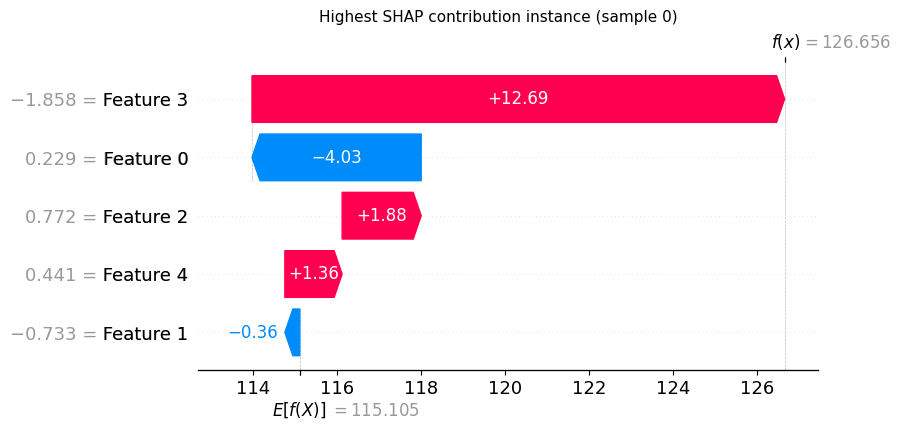

In [9]:
result = pipeline.explain_uncertainty(X_test[1:2, :])

En el caso se explicación global:

ExactExplainer explainer: 201it [00:38,  4.07it/s]                         


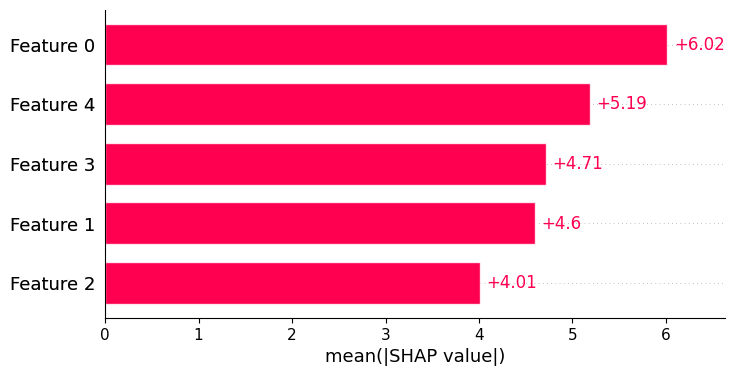

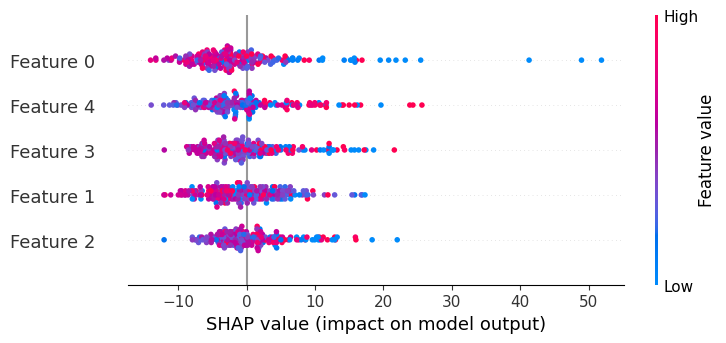

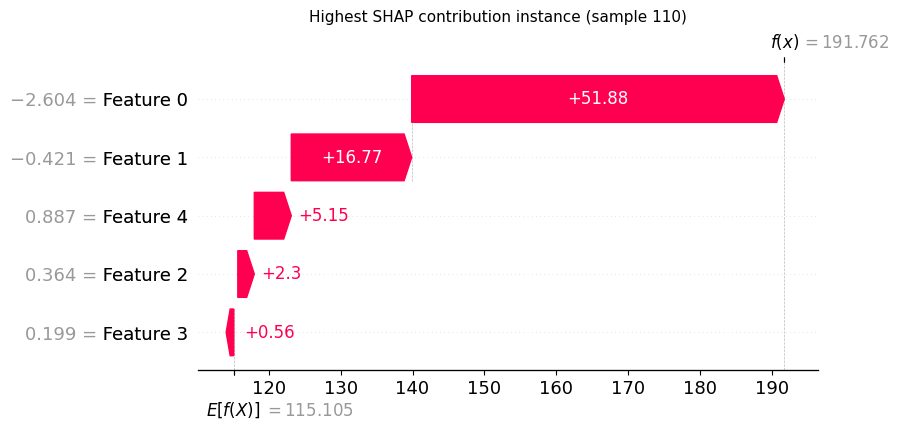

In [11]:
result = pipeline.explain_uncertainty(X_test)

### 5. Resultados

El diccionario retornado contiene los intervalos de prediccion y los valores SHAP.

In [12]:
print("Keys:", list(vars(result).keys()))
print(f"\nIntervalo promedio: {result.interval_width.mean():.2f}")
print(f"Intervalo min: {result.interval_width.min():.2f}")
print(f"Intervalo max: {result.interval_width.max():.2f}")

Keys: ['lower', 'upper', 'interval_width', 'explanation_values']

Intervalo promedio: 115.07
Intervalo min: 73.81
Intervalo max: 191.76


In [13]:
# SHAP values: cada fila es una instancia, cada columna la contribucion de un feature al ancho del intervalo
print("SHAP values shape:", result.explanation_values.values.shape)
print("\nEjemplo — contribucion de cada feature para la primera instancia de test:")
for i, val in enumerate(result.explanation_values.values[0]):
    print(f"  Feature {i}: {val:+.4f}")

SHAP values shape: (200, 5)

Ejemplo — contribucion de cada feature para la primera instancia de test:
  Feature 0: -11.3912
  Feature 1: -2.1076
  Feature 2: +2.1402
  Feature 3: +4.9162
  Feature 4: +6.5928


## Explanation using Partial Dependence Plots (PDP)

In [14]:
pipeline = UncertaintyExplanationPipeline(
    model,
    confidence=0.9,
    conformal_method="normalized", 
    xai_method="pdp",
)

In [15]:
pipeline.fit(X_train, y_train, X_calib, y_calib)

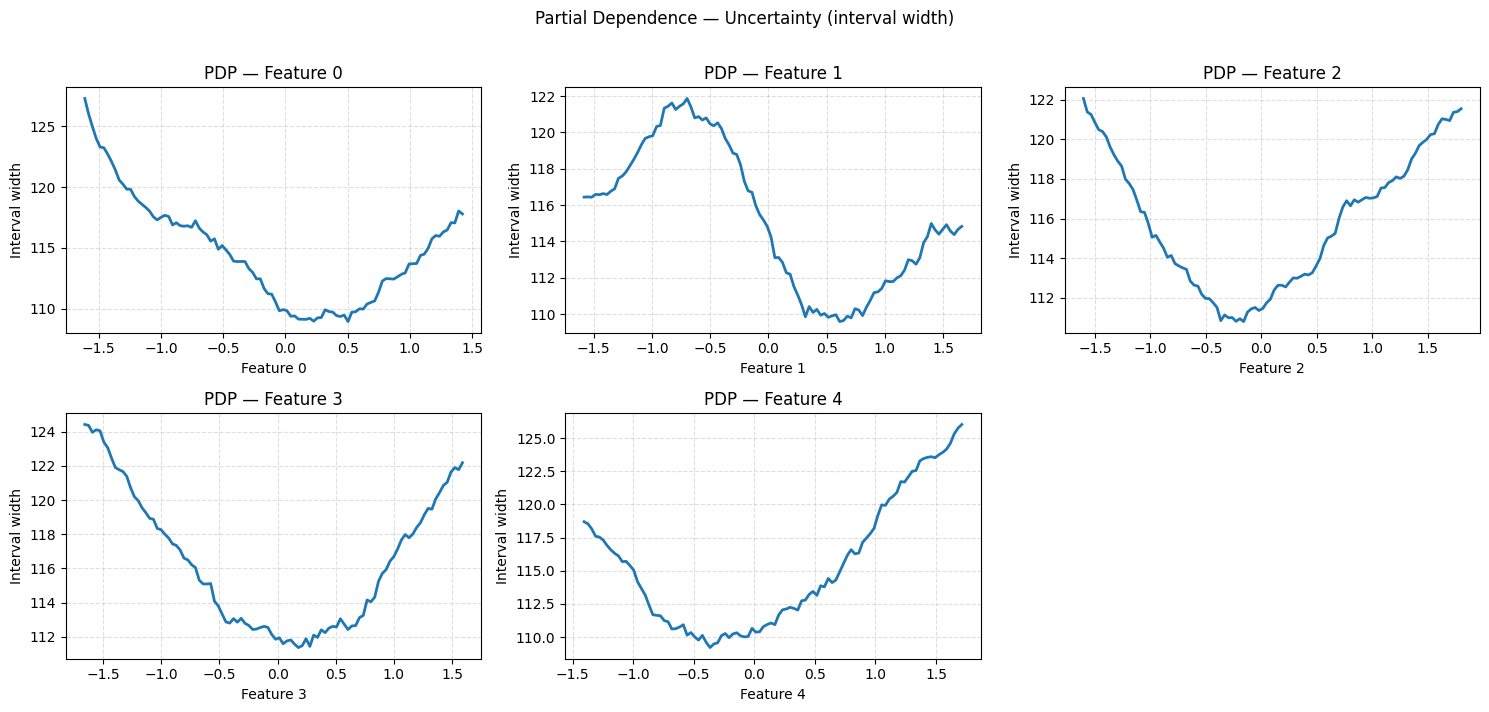

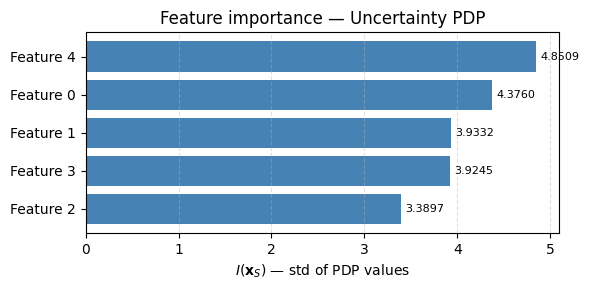

In [16]:
result = pipeline.explain_uncertainty(X_test)

In [17]:
print("Keys:", list(vars(result).keys()))
print(f"\nIntervalo promedio: {result.interval_width.mean():.2f}")
print(f"Intervalo min: {result.interval_width.min():.2f}")
print(f"Intervalo max: {result.interval_width.max():.2f}")

Keys: ['lower', 'upper', 'interval_width', 'explanation_values']

Intervalo promedio: 115.07
Intervalo min: 73.81
Intervalo max: 191.76


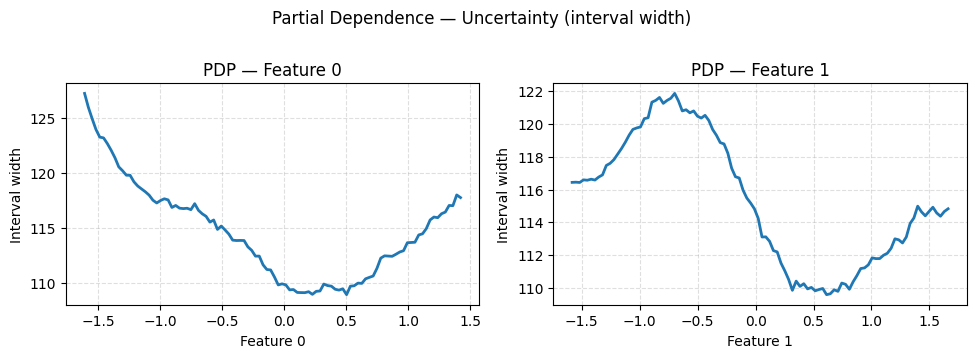

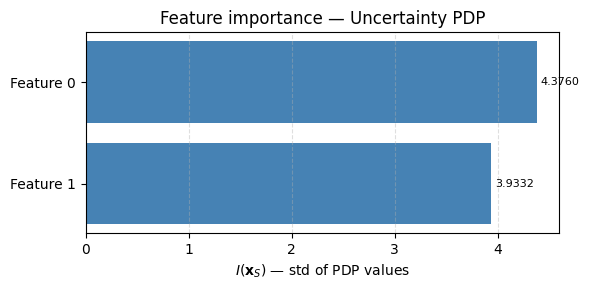

In [ ]:
result = pipeline.explain_uncertainty(X_test, features = [0, 1])

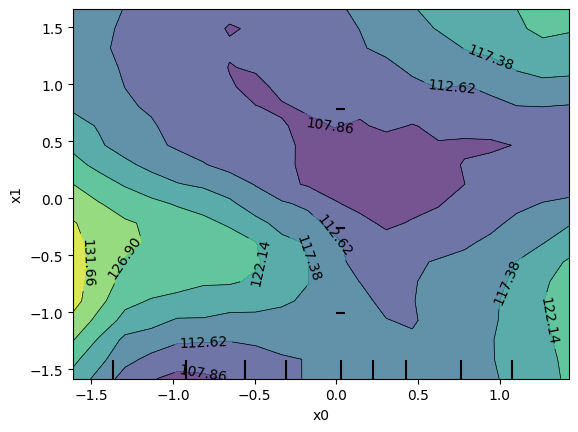

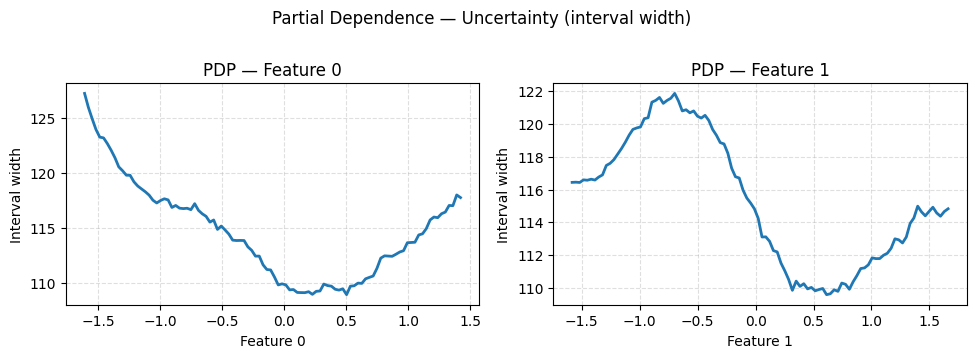

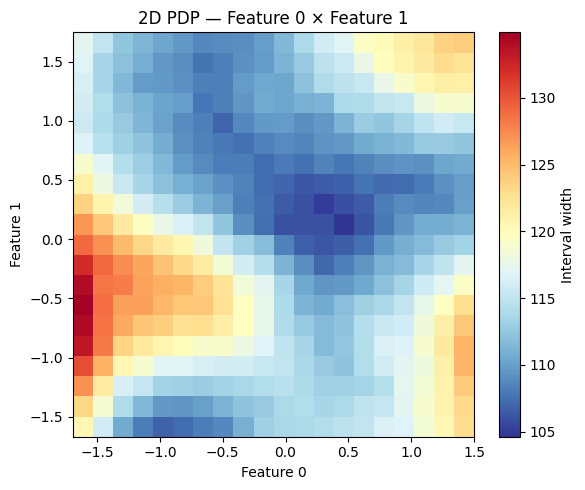

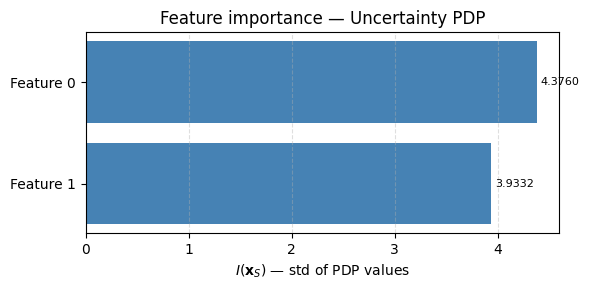

In [19]:
result = pipeline.explain_uncertainty(X_test, features = [(0, 1)])

## Explanation using LIME 

In [20]:
pipeline = UncertaintyExplanationPipeline(
    model,
    confidence=0.9,
    conformal_method="normalized", 
    xai_method="lime",
)

In [21]:
pipeline.fit(X_train, y_train, X_calib, y_calib)

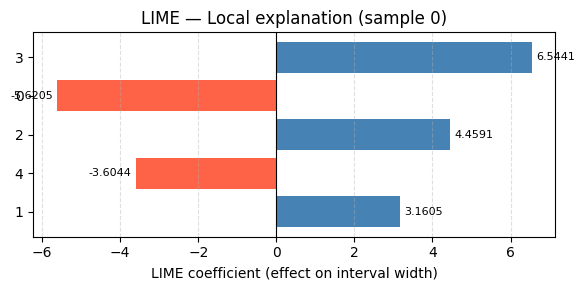

In [22]:
result = pipeline.explain_uncertainty(X_test[1:2, :])

### Usando CQR

In [23]:
from sklearn.ensemble import GradientBoostingRegressor

pipeline = UncertaintyExplanationPipeline(
    conformal_method="cqr",
    lower_model=GradientBoostingRegressor(loss="quantile", alpha=0.05),
    upper_model=GradientBoostingRegressor(loss="quantile", alpha=0.95),
    xai_method="shap",
)
pipeline.fit(X_train, y_train, X_calib, y_calib)


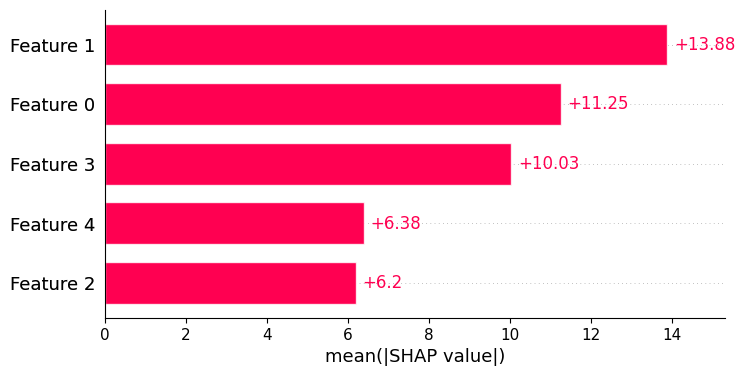

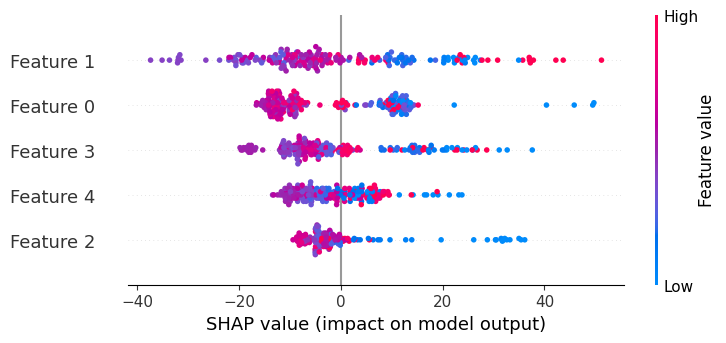

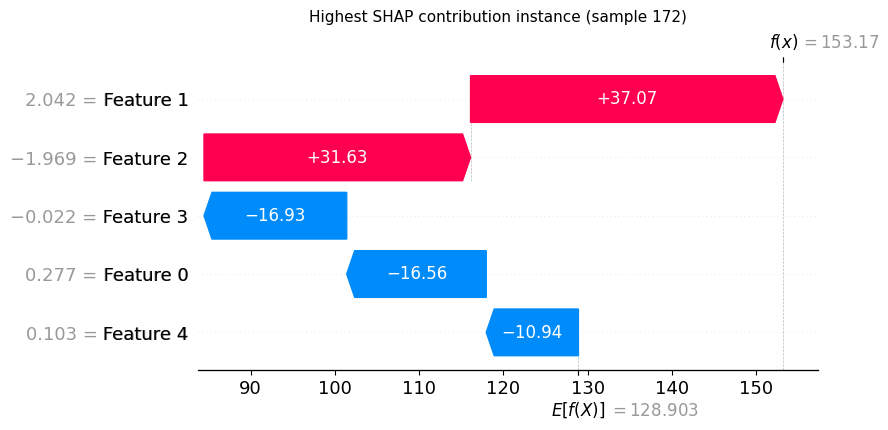

In [24]:
result = pipeline.explain_uncertainty(X_test)